<a href="https://colab.research.google.com/github/Ayush28-ai/Ayush28-ai/blob/main/Pet_Emotion_Detection_file_new_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Set Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = 'codingpanda5'  # Replace with your Kaggle username
os.environ['KAGGLE_KEY'] = '0c87ee462cdc408e405cd4f933c41ef0' # Replace with your Kaggle API key

# Install Kaggle CLI
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d danielshanbalico/dog-emotion --unzip

Dataset URL: https://www.kaggle.com/datasets/danielshanbalico/dog-emotion
License(s): CC0-1.0
100% 155M/155M [00:11<00:00, 13.5MB/s]



In [28]:
import os

data_path = "/content/Dog Emotion"

total_images = 0

for root, dirs, files in os.walk(data_path):
    image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    total_images += len(image_files)

print("Total number of images:", total_images)


Total number of images: 4000


In [29]:
from collections import defaultdict

class_counts = defaultdict(int)

for class_name in os.listdir(data_path):
    class_path = os.path.join(data_path, class_name)

    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("Images per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal images:", sum(class_counts.values()))


Images per class:
relaxed: 1000
sad: 1000
angry: 1000
happy: 1000

Total images: 4000


In [30]:
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
import pandas as pd

data_path = "/content/Dog Emotion"

# Load dataset
dataset = ImageFolder(root=data_path)

# Convert to DataFrame
df = pd.DataFrame(dataset.samples, columns=["path", "label"])

# First split: Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 2800
Validation: 600
Test: 600


In [31]:
import torchvision.transforms as transforms

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [32]:
from torch.utils.data import Dataset
from PIL import Image

class DogEmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "path"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [33]:
train_dataset = DogEmotionDataset(train_df, transform=train_transforms)
val_dataset = DogEmotionDataset(val_df, transform=val_test_transforms)
test_dataset = DogEmotionDataset(test_df, transform=val_test_transforms)
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders ready.")
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


DataLoaders ready.
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


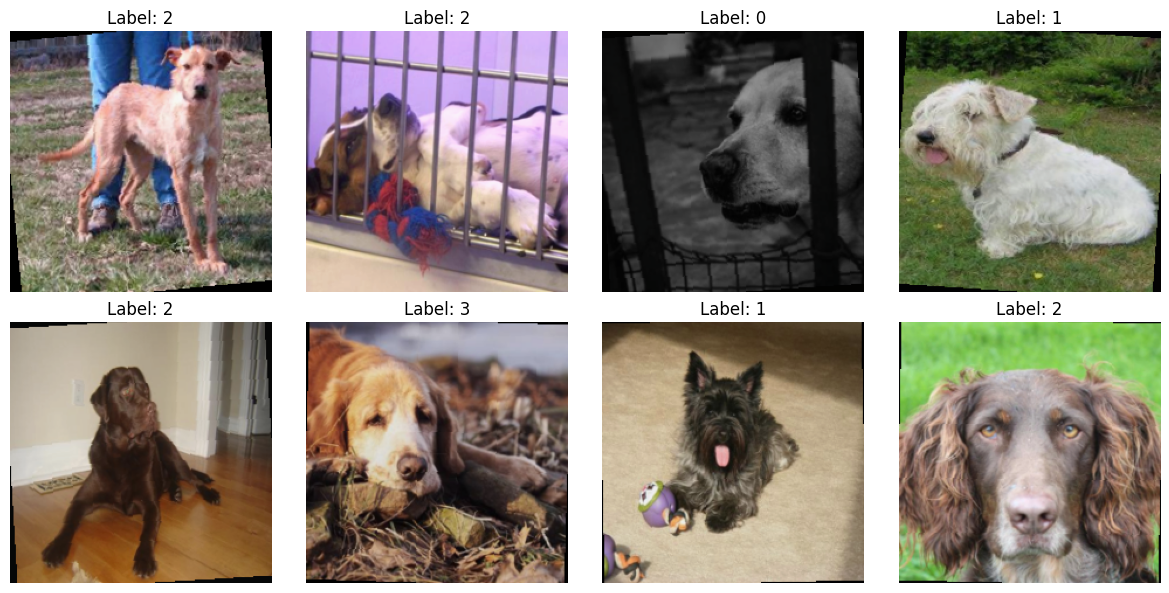

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels = next(iter(train_loader))

# If using GPU tensors, move to CPU
images = images.cpu()
labels = labels.cpu()

# Number of images to display
num_images = 8

plt.figure(figsize=(12, 6))

for i in range(num_images):
    plt.subplot(2, 4, i + 1)

    img = images[i]

    # Convert from tensor (C, H, W) -> (H, W, C)
    img = img.permute(1, 2, 0).numpy()

    # If normalized, unnormalize (adjust if you used different mean/std)
    # Example for ImageNet normalization:
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean

    # Clip values to valid range
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()

#model

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

In [36]:
class MoVE(nn.Module):
    def __init__(self, in_features, num_experts=4, embedding_dim=256, temperature=1.5):
        super(MoVE, self).__init__()

        self.temperature = temperature
        self.num_experts = num_experts

        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features, embedding_dim),
                nn.LayerNorm(embedding_dim),   # replaced BatchNorm
                nn.ReLU(),
                nn.Dropout(0.2 + 0.05*i)       # slight diversity
            )
            for i in range(num_experts)
        ])

        self.gate = nn.Linear(in_features, num_experts)

    def forward(self, x):
        # Expert outputs → (B, E, D)
        expert_outputs = torch.stack(
            [expert(x) for expert in self.experts], dim=1
        )

        # Gating
        gate_logits = self.gate(x) / self.temperature
        gate_weights = F.softmax(gate_logits, dim=1)  # (B, E)

        # Weighted sum
        mixed = torch.sum(gate_weights.unsqueeze(-1) * expert_outputs, dim=1)

        return mixed, gate_weights  # return weights for entropy loss

In [37]:
class ResNet50_MoVE(nn.Module):
    def __init__(self, num_classes=4, num_experts=4):
        super(ResNet50_MoVE, self).__init__()

        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.move = MoVE(
            in_features=in_features,
            num_experts=num_experts,
            embedding_dim=256,
            temperature=1.5
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)

        # Removed L2 normalization (important fix)

        x, gate_weights = self.move(x)
        x = self.classifier(x)

        return x, gate_weights  # return both

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet50_MoVE(
    num_classes=4,
    num_experts=4
).to(device)

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False

# Unfreeze deeper layers
for param in model.backbone.layer3.parameters():
    param.requires_grad = True

for param in model.backbone.layer4.parameters():
    param.requires_grad = True

# Fix BatchNorm behavior
for m in model.backbone.modules():
    if isinstance(m, nn.BatchNorm2d):
        m.eval()

In [39]:
optimizer = torch.optim.AdamW([
    {"params": model.backbone.layer3.parameters(), "lr": 3e-5},
    {"params": model.backbone.layer4.parameters(), "lr": 3e-5},
    {"params": model.move.parameters(), "lr": 1.5e-4},
    {"params": model.classifier.parameters(), "lr": 2e-4}  # slightly higher
], weight_decay=1e-4)  # reduced

In [40]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.03)

def compute_loss(outputs, labels, gate_weights, lambda_entropy=0.01):
    ce_loss = criterion(outputs, labels)

    # entropy to prevent expert collapse
    entropy = -torch.sum(gate_weights * torch.log(gate_weights + 1e-8), dim=1).mean()

    loss = ce_loss - lambda_entropy * entropy
    return loss, ce_loss, entropy

In [41]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',          # using validation accuracy
    factor=0.2,
    patience=1,
    min_lr=1e-6
)

In [43]:
import matplotlib.pyplot as plt
import torch
from google.colab import files   # for download

def train_model(model, train_loader, val_loader, epochs=30, patience=5):

    best_val_acc = 0.0
    counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs, gate_weights = model(images)
            loss, ce_loss, entropy = compute_loss(outputs, labels, gate_weights)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        avg_train_loss = running_loss / total

        # ---------- VALIDATION ----------
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs, gate_weights = model(images)
                loss, _, _ = compute_loss(outputs, labels, gate_weights)

                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        avg_val_loss = val_loss / val_total

        scheduler.step(val_acc)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")

        # ---------- SAVE BEST ----------
        if val_acc > best_val_acc:
            best_val_acc = val_acc

            # 🔥 1. Save checkpoint (for training resume)
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc
            }, "checkpoint.pth")

            # 🔥 2. Save WEIGHTS ONLY (BEST FOR YOU)
            torch.save(model.state_dict(), "model_weights.pth")

            # 🔥 3. Save FULL MODEL (optional)
            torch.save(model, "full_model.pth")

            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("\nEarly stopping triggered!")
                break

    print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

    # Load best weights
    model.load_state_dict(torch.load("model_weights.pth", map_location=device))
    model.to(device)
    model.eval()

    # Plot graphs
    plot_training(history)

    # 🔥 DOWNLOAD FILES

    return model, history

In [44]:
model, history = train_model(model, train_loader, val_loader)

Epoch 01/30 | Train Loss: 1.1488 | Train Acc: 53.68% | Val Loss: 0.8729 | Val Acc: 67.50%
Epoch 02/30 | Train Loss: 0.6361 | Train Acc: 78.82% | Val Loss: 0.5471 | Val Acc: 82.33%
Epoch 03/30 | Train Loss: 0.4183 | Train Acc: 88.07% | Val Loss: 0.5062 | Val Acc: 83.17%
Epoch 04/30 | Train Loss: 0.3146 | Train Acc: 92.18% | Val Loss: 0.4951 | Val Acc: 85.17%
Epoch 05/30 | Train Loss: 0.2575 | Train Acc: 95.32% | Val Loss: 0.4910 | Val Acc: 85.00%
Epoch 06/30 | Train Loss: 0.2131 | Train Acc: 96.75% | Val Loss: 0.4767 | Val Acc: 85.67%
Epoch 07/30 | Train Loss: 0.1814 | Train Acc: 98.00% | Val Loss: 0.4926 | Val Acc: 86.67%
Epoch 08/30 | Train Loss: 0.1677 | Train Acc: 98.46% | Val Loss: 0.5129 | Val Acc: 86.67%
Epoch 09/30 | Train Loss: 0.1563 | Train Acc: 98.89% | Val Loss: 0.5175 | Val Acc: 85.83%
Epoch 10/30 | Train Loss: 0.1520 | Train Acc: 99.14% | Val Loss: 0.5120 | Val Acc: 86.33%
Epoch 11/30 | Train Loss: 0.1479 | Train Acc: 99.29% | Val Loss: 0.5014 | Val Acc: 87.50%
Epoch 12/3

NameError: name 'plot_training' is not defined

In [45]:
from google.colab import files

files.download("model_weights.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("model_weights.pth")

In [ ]:
def plot_training(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Accuracy Plot
    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

    # Loss Plot
    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    patience=5
)

Epoch 01/20 | Train Loss: 1.1296 | Train Acc: 52.54% | Val Loss: 0.8719 | Val Acc: 67.17%
Epoch 02/20 | Train Loss: 0.6339 | Train Acc: 79.39% | Val Loss: 0.5721 | Val Acc: 80.00%
Epoch 03/20 | Train Loss: 0.4181 | Train Acc: 87.68% | Val Loss: 0.5327 | Val Acc: 82.50%
Epoch 04/20 | Train Loss: 0.3301 | Train Acc: 91.64% | Val Loss: 0.5160 | Val Acc: 83.50%
Epoch 05/20 | Train Loss: 0.2500 | Train Acc: 95.11% | Val Loss: 0.5814 | Val Acc: 82.17%
Epoch 06/20 | Train Loss: 0.2085 | Train Acc: 96.71% | Val Loss: 0.4677 | Val Acc: 85.00%
Epoch 07/20 | Train Loss: 0.1840 | Train Acc: 97.82% | Val Loss: 0.5319 | Val Acc: 83.67%
Epoch 08/20 | Train Loss: 0.1696 | Train Acc: 98.54% | Val Loss: 0.4909 | Val Acc: 85.50%
Epoch 09/20 | Train Loss: 0.1560 | Train Acc: 99.14% | Val Loss: 0.5208 | Val Acc: 85.33%
Epoch 10/20 | Train Loss: 0.1498 | Train Acc: 99.39% | Val Loss: 0.5213 | Val Acc: 86.33%
Epoch 11/20 | Train Loss: 0.1518 | Train Acc: 99.18% | Val Loss: 0.5178 | Val Acc: 84.50%
Epoch 12/2

RuntimeError: Error(s) in loading state_dict for ResNet50_MoVE:
	Missing key(s) in state_dict: "backbone.conv1.weight", "backbone.bn1.weight", "backbone.bn1.bias", "backbone.bn1.running_mean", "backbone.bn1.running_var", "backbone.layer1.0.conv1.weight", "backbone.layer1.0.bn1.weight", "backbone.layer1.0.bn1.bias", "backbone.layer1.0.bn1.running_mean", "backbone.layer1.0.bn1.running_var", "backbone.layer1.0.conv2.weight", "backbone.layer1.0.bn2.weight", "backbone.layer1.0.bn2.bias", "backbone.layer1.0.bn2.running_mean", "backbone.layer1.0.bn2.running_var", "backbone.layer1.0.conv3.weight", "backbone.layer1.0.bn3.weight", "backbone.layer1.0.bn3.bias", "backbone.layer1.0.bn3.running_mean", "backbone.layer1.0.bn3.running_var", "backbone.layer1.0.downsample.0.weight", "backbone.layer1.0.downsample.1.weight", "backbone.layer1.0.downsample.1.bias", "backbone.layer1.0.downsample.1.running_mean", "backbone.layer1.0.downsample.1.running_var", "backbone.layer1.1.conv1.weight", "backbone.layer1.1

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, test_loader, class_names):

    model.eval()
    all_preds = []
    all_labels = []

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs, _ = model(images)  # MoVE returns (outputs, gate_weights)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Test Accuracy
    test_acc = 100 * correct / total
    print(f"\nTest Accuracy: {test_acc:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(values_format='d', cmap='Blues')
    plt.title("Confusion Matrix (Test Set)")
    plt.grid(False)
    plt.show()

    return test_acc, cm


Test Accuracy: 84.67%


<Figure size 640x480 with 0 Axes>

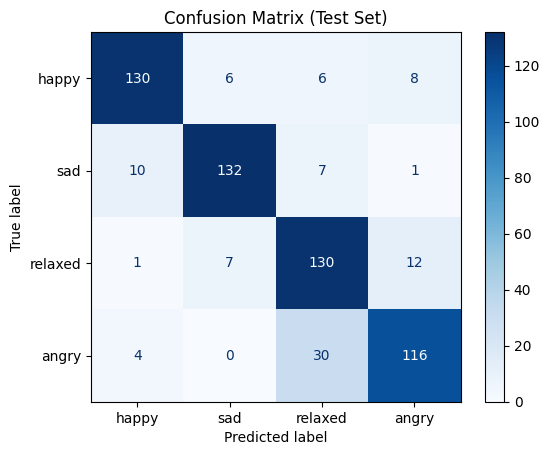

In [ ]:
class_names = ["happy", "sad", "relaxed" , "angry",]  # change to your classes

test_acc, cm = evaluate_model(
    model,
    test_loader,
    class_names
)

<Figure size 640x480 with 0 Axes>

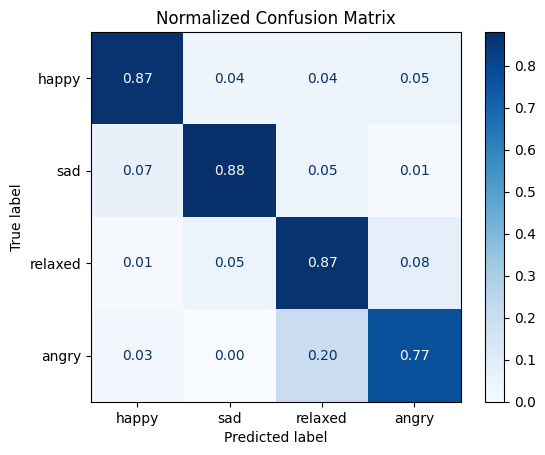

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp.plot(values_format='.2f', cmap='Blues')
plt.title("Normalized Confusion Matrix")
plt.grid(False)
plt.show()